# 03 — Results Visualisation

Export figures after a completed **evaluation + robustness** run (full corpus recommended: ≥ 30 narratives).

```bash
python scripts/export_results.py --run-id <run_id> --eval-figures
```

Produces under `outputs/figures/<run_id>/`:
- **Main (filtered):** hallucination charts on high-reliability extractions (score ≥ 0.8)
- **`unfiltered/`:** same charts on all narratives (sensitivity)
- **`robustness/`:** reliability distribution, by-strategy, hallucination × reliability group
- **`analysis/`:** per-feature breakdown CSVs (sign inversion, rank-set gaps, omissions, fabrications)

**Pilot note:** `pilot_run_20260518T074326_cadfd5` has only 2 rows — the export CLI will refuse figures until `min_narratives_for_figures` (default 30) is met. Use the cells below for layout checks only.

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
from dotenv import load_dotenv

load_dotenv('../.env')

from src.config import load_config
from src.storage import list_runs, load_narratives_csv, narratives_csv_path, run_dir

cfg = load_config('../config/default.yaml')

runs = list_runs(f'../{cfg.storage.generation_dir}')
pd.DataFrame(runs)

,run_id,path,n_narratives
0,pilot_run_20260518T135815_bdad28,..\outputs\generation\pilot_run_20260518T13581...,17342
1,pilot_run_20260518T133147_4b0aad,..\outputs\generation\pilot_run_20260518T13314...,577
2,pilot_run_20260518T130411_e9f98c,..\outputs\generation\pilot_run_20260518T13041...,577
3,pilot_run_20260518T123547_d896fe,..\outputs\generation\pilot_run_20260518T12354...,416
4,pilot_run_20260518T122429_35ddd8,..\outputs\generation\pilot_run_20260518T12242...,249
5,pilot_run_20260518T074326_cadfd5,..\outputs\generation\pilot_run_20260518T07432...,83
6,pilot_run_20260518T073857_6d094a,..\outputs\generation\pilot_run_20260518T07385...,48
7,pilot_run_20260518T073743_f2e217,..\outputs\generation\pilot_run_20260518T07374...,48


In [3]:
# Example: load narratives CSV for the latest run
RUN_ID = runs[0]['run_id'] if runs else None
print('Run:', RUN_ID)

import os

if RUN_ID:
    # Use absolute path to outputs
    abs_csv_path = os.path.abspath(f'../outputs/generation/{RUN_ID}/narratives.csv')
    narr_df = load_narratives_csv(abs_csv_path)
    print(f'{len(narr_df)} narratives in {abs_csv_path}')
    narr_df.head()

Run: pilot_run_20260518T135815_bdad28
300 narratives in c:\xAI\xAI-research\outputs\generation\pilot_run_20260518T135815_bdad28\narratives.csv


## Hallucination charts (layout check on pilot)

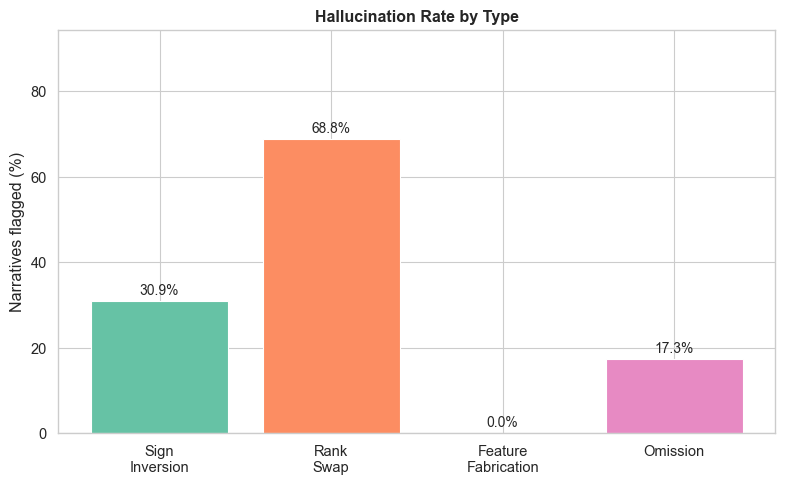

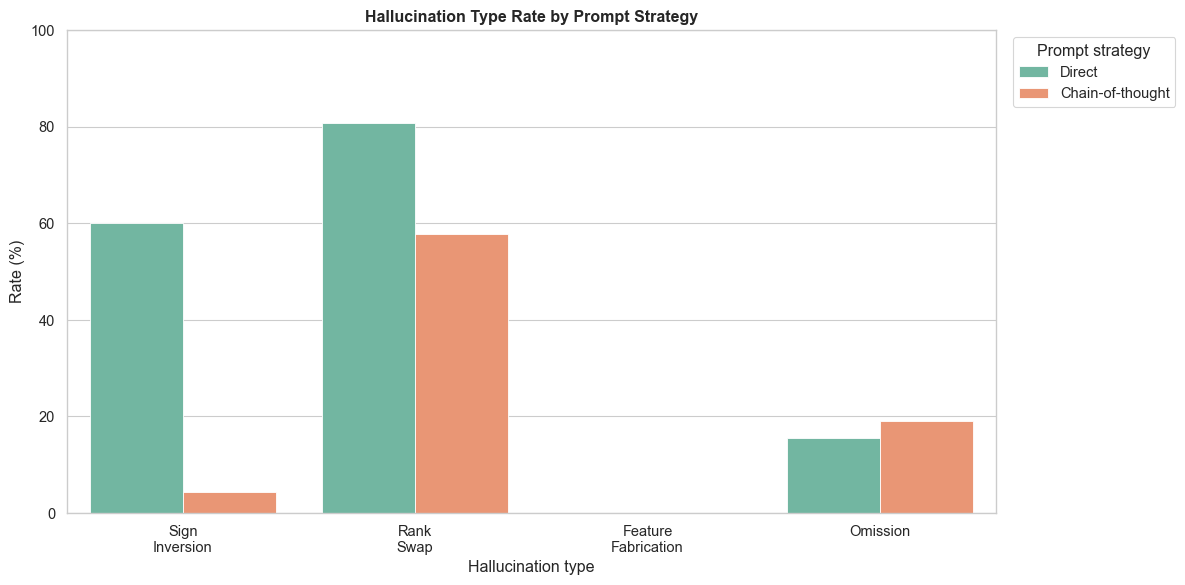

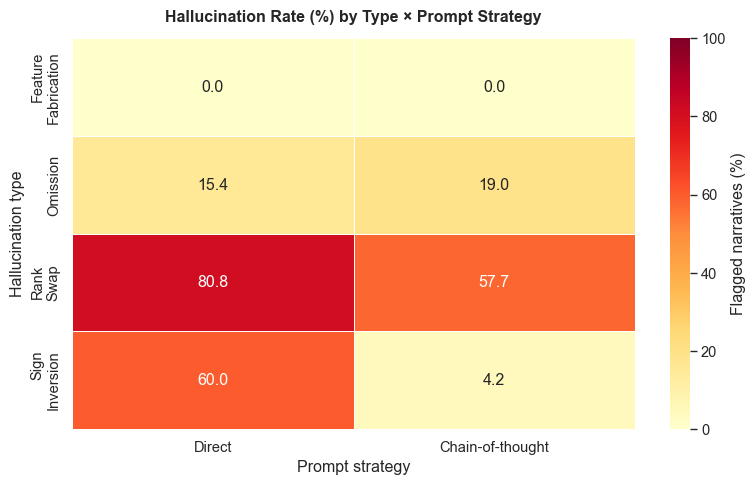

In [7]:
import matplotlib.pyplot as plt

EVAL_RUN_ID = 'pilot_run_20260518T135815_bdad28'  # 2 rows — layout only
eval_csv = f'../outputs/evaluations/{EVAL_RUN_ID}/evaluations.csv'
evals_df = pd.read_csv(eval_csv)
evals_df = evals_df[evals_df['parse_error'].fillna('').astype(str) == '']

from src.visualisation.hallucination_rates import plot_rates_by_type, plot_type_by_strategy
from src.visualisation.heatmaps import plot_type_strategy_heatmap

fig = plot_rates_by_type(evals_df); plt.show()
fig = plot_type_by_strategy(evals_df); plt.show()
fig = plot_type_strategy_heatmap(evals_df); plt.show()

## Robustness charts (pilot)

c:\xAI\xAI-research\notebooks\..\src\visualisation\robustness_plots.py:181: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


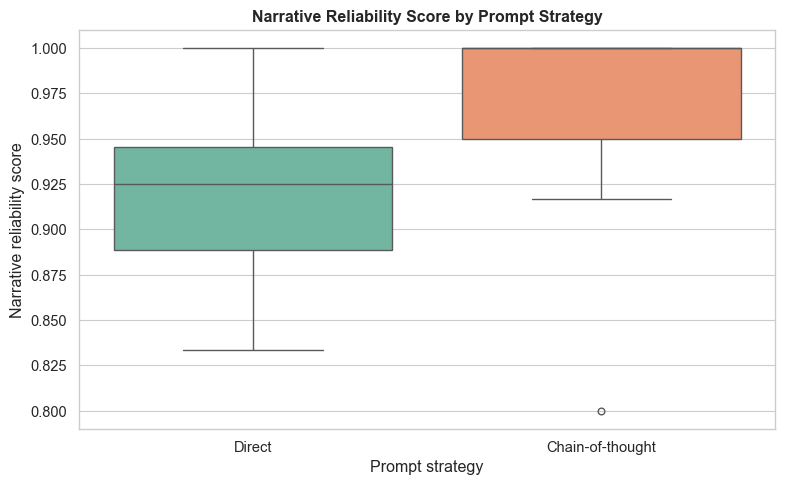

In [9]:
from src.visualisation.robustness_plots import (
    load_robustness_df,
    plot_reliability_by_strategy,
    plot_hallucination_by_reliability_group,
)

rb_df = load_robustness_df(evals_df)

# The following boxplot displays the reliability of generated narratives, grouped by the prompt strategy used.
# "Reliability" here quantifies how stable a narrative is to small input perturbations—higher values mean more robust explanations.
# Each box shows the distribution of reliability scores for the narratives produced with a given strategy:
# - The box covers the interquartile range (middle 50% of scores).
# - The line inside the box is the median reliability.
# - Whiskers and outliers show the spread and individual extremes.
# This helps compare which prompt strategies yield more consistent, dependable outputs.

fig = plot_reliability_by_strategy(rb_df)
plt.show()

## Hallucination breakdown analysis

Per-feature tables parsed from evaluation `notes` (and `unknown_features` for fabrications):

1. **Sign inversion** — counts per feature and direction (`narrative ±1` vs `SHAP ±1`)
2. **Missing from rank set** — SHAP top-*k* features absent from the narrative top-*k* set (rank-swap cases)
3. **Omissions** — top-*k* SHAP features not mentioned in the narrative
4. **Fabrication list** — unknown feature names with narrative identifiers

In [6]:
from src.visualisation.hallucination_analysis import summarize_hallucination_breakdown

# Use the same run as above, or pick the latest evaluated run
EVAL_RUN_ID = "pilot_run_20260518T135815_bdad28"
#EVAL_RUN_ID = EVAL_RUN_ID if 'EVAL_RUN_ID' in dir() else (runs[0]['run_id'] if runs else None)
eval_csv = f'../outputs/evaluations/{EVAL_RUN_ID}/evaluations.csv'
evals_df = pd.read_csv(eval_csv)
evals_df = evals_df[evals_df['parse_error'].fillna('').astype(str) == '']

breakdown = summarize_hallucination_breakdown(evals_df)

print('Sign inversion cases per variable and direction')
display(breakdown['sign_inversion_by_feature'])

print('Missing from rank set per variable (in SHAP top-k, not narrative top-k)')
display(breakdown['missing_from_rank_set_by_feature'])

print('Overall omissions per variable')
display(breakdown['omissions_by_feature'])

print('Fabrication list')
display(breakdown['fabrication_list'])

Sign inversion cases per variable and direction


,feature,narrative_sign,shap_sign,direction,count
0,marital_status_Non_Married,-1,1,narrative -1 vs SHAP +1,45
1,relationship_Non_Husband,-1,1,narrative -1 vs SHAP +1,32
2,occupation_Other,-1,1,narrative -1 vs SHAP +1,22
3,age,-1,1,narrative -1 vs SHAP +1,13
4,native_country_US,1,-1,narrative +1 vs SHAP -1,9
5,capital_gain,1,-1,narrative +1 vs SHAP -1,7
6,marital_status_Non_Married,1,-1,narrative +1 vs SHAP -1,7
7,race_White,-1,1,narrative -1 vs SHAP +1,7
8,race_White,1,-1,narrative +1 vs SHAP -1,7
9,hours_per_week,1,-1,narrative +1 vs SHAP -1,6


Missing from rank set per variable (in SHAP top-k, not narrative top-k)


,feature,count
0,relationship_Non_Husband,70
1,occupation_Other,67
2,sex_Male,44
3,marital_status_Non_Married,30
4,hours_per_week,23
5,age,9
6,capital_loss,2
7,capital_gain,1
8,native_country_US,1
9,workclass_Private,1


Overall omissions per variable


,feature,count
0,relationship_Non_Husband,21
1,occupation_Other,14
2,sex_Male,12
3,hours_per_week,3
4,marital_status_Non_Married,3
5,capital_gain,1
6,age,1
7,workclass_Private,1


Fabrication list


,feature,eval_id,narrative_id,instance_id,model_id,prompt_strategy
